In [1]:
import overpy
import geopandas as gpd
import pandas as pd
import requests
import json
import time
import os

os.makedirs("../data/raw", exist_ok=True)
os.makedirs("../data/processed", exist_ok=True)

In [2]:
# Barcelona bounding box: south, west, north, east
BBOX = (41.3200, 2.0695, 41.4700, 2.2280)

print(f"Bounding box set: {BBOX}")

Bounding box set: (41.32, 2.0695, 41.47, 2.228)


In [3]:
api = overpy.Overpass()

query = f"""
[out:json][timeout:60];
(
  node["shop"="supermarket"]({BBOX[0]},{BBOX[1]},{BBOX[2]},{BBOX[3]});
  node["shop"="convenience"]({BBOX[0]},{BBOX[1]},{BBOX[2]},{BBOX[3]});
  node["shop"="greengrocer"]({BBOX[0]},{BBOX[1]},{BBOX[2]},{BBOX[3]});
  node["shop"="butcher"]({BBOX[0]},{BBOX[1]},{BBOX[2]},{BBOX[3]});
  node["shop"="bakery"]({BBOX[0]},{BBOX[1]},{BBOX[2]},{BBOX[3]});
  node["amenity"="marketplace"]({BBOX[0]},{BBOX[1]},{BBOX[2]},{BBOX[3]});
);
out body;
"""

print("Querying Overpass API...")
result = api.query(query)
print(f"Found {len(result.nodes)} grocery POIs")

Querying Overpass API...
Found 3133 grocery POIs


In [4]:
records = []
for node in result.nodes:
    records.append({
        "osm_id":   node.id,
        "shop_type": node.tags.get("shop") or node.tags.get("amenity"),
        "name":     node.tags.get("name", "Unknown"),
        "lat":      float(node.lat),
        "lon":      float(node.lon),
        "brand":    node.tags.get("brand", None),
        "organic":  node.tags.get("organic", None),
    })

df_pois = pd.DataFrame(records)
print(df_pois["shop_type"].value_counts())
df_pois.head()

shop_type
supermarket    1250
bakery          751
convenience     611
greengrocer     336
butcher         174
marketplace      11
Name: count, dtype: int64


,osm_id,shop_type,name,lat,lon,brand,organic
0,364741238,convenience,IKEA Swedish Food Market,41.394893,2.152061,IKEA,None
1,364844476,supermarket,Open Cor,41.391002,2.125651,None,None
2,402894808,convenience,Supermarket,41.412370,2.154647,None,None
3,449384558,convenience,Mercat Felip II,41.422194,2.185435,None,None
4,451795996,supermarket,Condis,41.446813,2.174794,Condis,None


In [5]:
gdf_pois = gpd.GeoDataFrame(
    df_pois,
    geometry=gpd.points_from_xy(df_pois.lon, df_pois.lat),
    crs="EPSG:4326"
)

gdf_pois.to_file("../data/raw/barcelona_grocery_pois.geojson", driver="GeoJSON")
print(f"Saved {len(gdf_pois)} POIs to data/raw/barcelona_grocery_pois.geojson")

Saved 3133 POIs to data/raw/barcelona_grocery_pois.geojson


In [7]:
# Ajuntament de Barcelona open data — neighbourhood (barri) boundaries
import json

# Primary: GitHub-hosted official BCN barris GeoJSON (most reliable, CC-BY licensed)
BARRIS_URL = "https://raw.githubusercontent.com/martgnz/bcn-geodata/master/barris/barris.geojson"

# Fallback: Ajuntament direct download
BARRIS_FALLBACK = "https://opendata-ajuntament.barcelona.cat/data/dataset/20170706-districtes-barris/resource/cd800462-f326-429f-a67a-c69b7fc4c50a/download/Unitats_Administratives_BCN.geojson"

print("Downloading neighbourhood boundaries...")

for url in [BARRIS_URL, BARRIS_FALLBACK]:
    try:
        response = requests.get(url, timeout=30)
        response.raise_for_status()
        
        # Validate it's actually JSON before saving
        json.loads(response.content)
        
        with open("../data/raw/barcelona_barris.geojson", "wb") as f:
            f.write(response.content)
        print(f"Success from: {url}")
        break
    except Exception as e:
        print(f"Failed ({url}): {e}, trying fallback...")

gdf_barris = gpd.read_file("../data/raw/barcelona_barris.geojson")
print(f"Loaded {len(gdf_barris)} neighbourhoods")
print(gdf_barris.columns.tolist())
gdf_barris.head()

Success from: https://raw.githubusercontent.com/martgnz/bcn-geodata/master/barris/barris.geojson
Loaded 73 neighbourhoods
['ID_ANNEX', 'ANNEXDESCR', 'ID_TEMA', 'TEMA_DESCR', 'ID_CONJUNT', 'CONJ_DESCR', 'ID_SUBCONJ', 'SCONJ_DESC', 'ID_ELEMENT', 'ELEM_DESCR', 'NIVELL', 'NDESCR_CA', 'NDESCR_ES', 'NDESCR_EN', 'TERME', 'DISTRICTE', 'BARRI', 'AEB', 'SEC_CENS', 'GRANBARRI', 'ZUA', 'AREA_I', 'LITERAL', 'PERIMETRE', 'AREA', 'ORD_REPRES', 'CODI_UA', 'TIPUS_UA', 'NOM', 'WEB1', 'WEB2', 'WEB3', 'DOCUMENTA', 'RANGESCALA', 'TIPUS_POL', 'GRUIX_ID', 'GRUIXDIMEN', 'ESTIL_ID', 'ESTIL_QGIS', 'VALOR1QGIS', 'VALOR2QGIS', 'COL_FARCIT', 'FCOL_DESCR', 'FHEX_COLOR', 'COL_DESCR', 'HEX_COLOR7', 'geometry']


,ID_ANNEX,ANNEXDESCR,ID_TEMA,TEMA_DESCR,ID_CONJUNT,CONJ_DESCR,ID_SUBCONJ,SCONJ_DESC,ID_ELEMENT,ELEM_DESCR,...,ESTIL_ID,ESTIL_QGIS,VALOR1QGIS,VALOR2QGIS,COL_FARCIT,FCOL_DESCR,FHEX_COLOR,COL_DESCR,HEX_COLOR7,geometry
0,01,Grup - I,0104,Unitats Administratives,010413,Barris,01041301,Barri,0104130101,Límit de barri,...,0,Sòlid,0,0,41,NULL,#E66900,NULL,#73A88F,"POLYGON ((2.16471 41.38593, 2.16936 41.38554, ..."
1,01,Grup - I,0104,Unitats Administratives,010413,Barris,01041301,Barri,0104130101,Límit de barri,...,0,Sòlid,0,0,41,NULL,#E66900,NULL,#73A88F,"POLYGON ((2.17701 41.38525, 2.17873 41.38396, ..."
2,01,Grup - I,0104,Unitats Administratives,010413,Barris,01041301,Barri,0104130101,Límit de barri,...,0,Sòlid,0,0,41,NULL,#E66900,NULL,#73A88F,"POLYGON ((2.19623 41.38745, 2.19631 41.38745, ..."
3,01,Grup - I,0104,Unitats Administratives,010413,Barris,01041301,Barri,0104130101,Límit de barri,...,0,Sòlid,0,0,41,NULL,#E66900,NULL,#73A88F,"POLYGON ((2.17091 41.40182, 2.17221 41.40083, ..."
4,01,Grup - I,0104,Unitats Administratives,010413,Barris,01041301,Barri,0104130101,Límit de barri,...,0,Sòlid,0,0,41,NULL,#E66900,NULL,#73A88F,"POLYGON ((2.15736 41.39331, 2.15847 41.39245, ..."


In [10]:
# Income data manually downloaded from:
# https://opendata-ajuntament.barcelona.cat/data/en/dataset/renda-disponible-llars-bcn
# Saved as: data/raw/barcelona_income.csv

df_income = pd.read_csv("../data/raw/barcelona_income.csv", sep=None, engine="python")

# Standardise column names
df_income.columns = [c.split(".")[-1].strip() for c in df_income.columns]

print(df_income.shape)
print(df_income.columns.tolist())
df_income.head()

(1068, 7)
['Any', 'Codi_Districte', 'Nom_Districte', 'Codi_Barri', 'Nom_Barri', 'Seccio_Censal', 'Import_Euros']


,Any,Codi_Districte,Nom_Districte,Codi_Barri,Nom_Barri,Seccio_Censal,Import_Euros
0,2022,1,Ciutat Vella,1,el Raval,1,15940
1,2022,1,Ciutat Vella,1,el Raval,2,13841
2,2022,1,Ciutat Vella,1,el Raval,3,12732
3,2022,1,Ciutat Vella,1,el Raval,4,15749
4,2022,1,Ciutat Vella,1,el Raval,5,13190


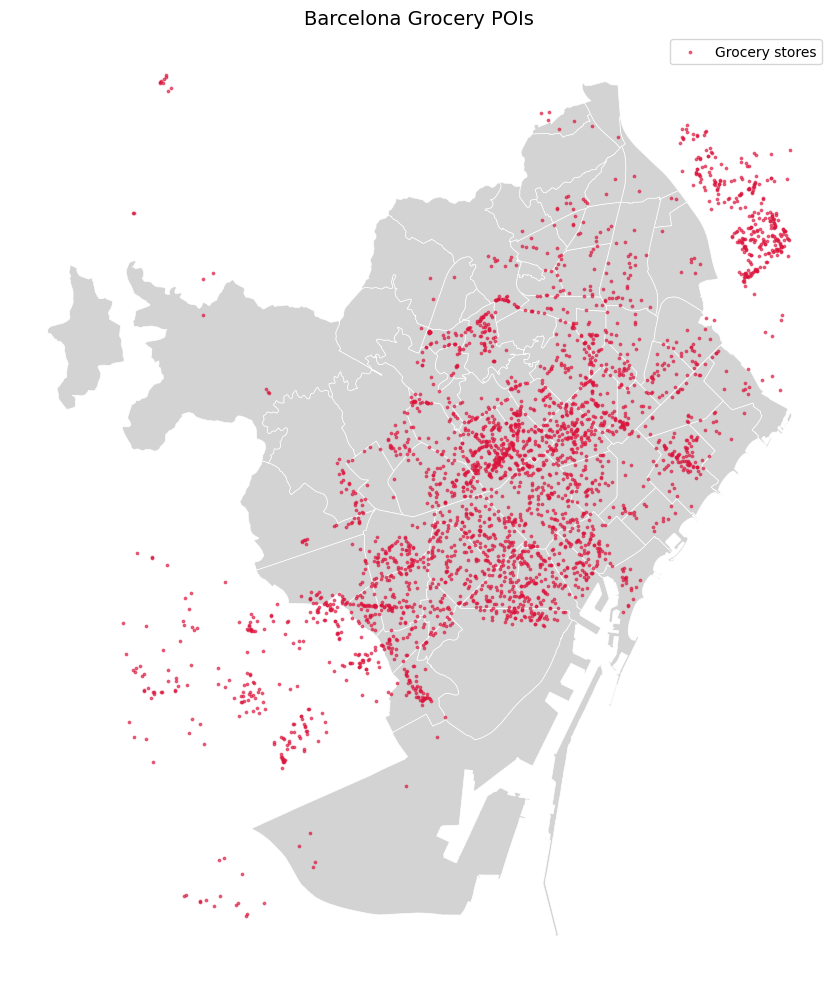

Plot saved to outputs/maps/


In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))
gdf_barris.plot(ax=ax, color="lightgrey", edgecolor="white", linewidth=0.5)
gdf_pois.plot(ax=ax, markersize=3, color="crimson", alpha=0.6, label="Grocery stores")
ax.set_title("Barcelona Grocery POIs", fontsize=14)
ax.set_axis_off()
plt.legend()
plt.tight_layout()
plt.savefig("../outputs/maps/01_poi_overview.png", dpi=150)
plt.show()
print("Plot saved to outputs/maps/")